# Hessians and Concavity

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture on **Hessians and concavity**
(Week 3 — Optimization in Neural Networks and Newton's Method).

This notebook explains:

- the **multivariable second-derivative test** — using the Hessian's **eigenvalues**
- **positive definite** (all eigenvalues $>0$) → concave up → **local minimum**
- **negative definite** (all eigenvalues $<0$) → concave down → **local maximum**
- **indefinite** (mixed signs) → **saddle point**
- three worked surfaces (bowl, dome, saddle) and a general classifier

This notebook follows the repository `GUIDELINES.md` template and continues directly from
*The Hessian*.

## 1. Recap: the one-variable test

For $f(x)$ at a point with $f'(x) = 0$:

- $f''(x) > 0$ → concave up → **local minimum**,
- $f''(x) < 0$ → concave down → **local maximum**,
- $f''(x) = 0$ → **inconclusive**.

In many variables the same idea holds, but the second derivative is the **Hessian matrix** —
so we need a way to say whether a *matrix* is "positive" or "negative".

## 2. Checking a matrix: eigenvalues

> *"How do we check if a matrix is positive or negative? You look at the eigenvalues."*

The Hessian's **eigenvalues** play the role of the sign of $f''$:

- **all eigenvalues $> 0$** → **positive definite** → concave up → **minimum**,
- **all eigenvalues $< 0$** → **negative definite** → concave down → **maximum**,
- **mixed signs** → indefinite → **saddle point**,
- **any eigenvalue $= 0$** → inconclusive.

We illustrate with three surfaces.

## 3. Example 1 — a minimum (positive definite)

$$
f(x,y) = 2x^2 + 3y^2 - xy
$$

A bowl ("happy face") with its minimum at $(0,0)$. Its Hessian is
$\begin{bmatrix} 4 & -1 \\ -1 & 6 \end{bmatrix}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

x, y = sp.symbols('x y')

def hessian_and_eigs(expr):
    H = np.array(sp.hessian(expr, (x, y)).subs({x: 0, y: 0})).astype(float)
    return H, np.linalg.eigvalsh(H)

f1 = 2*x**2 + 3*y**2 - x*y
H1, e1 = hessian_and_eigs(f1)
print("Hessian:", H1.tolist())
print("eigenvalues:", np.round(e1, 4), "-> all positive -> positive definite -> MINIMUM")

Hessian: [[4.0, -1.0], [-1.0, 6.0]]
eigenvalues: [3.5858 6.4142] -> all positive -> positive definite -> MINIMUM


## 4. Example 2 — a maximum (negative definite)

$$
f(x,y) = -2x^2 - 3y^2 - xy + 15
$$

A dome ("sad face") with its maximum at $(0,0)$. Hessian
$\begin{bmatrix} -4 & -1 \\ -1 & -6 \end{bmatrix}$.

In [2]:
f2 = -2*x**2 - 3*y**2 - x*y + 15
H2, e2 = hessian_and_eigs(f2)
print("Hessian:", H2.tolist())
print("eigenvalues:", np.round(e2, 4), "-> all negative -> negative definite -> MAXIMUM")

Hessian: [[-4.0, -1.0], [-1.0, -6.0]]
eigenvalues: [-6.4142 -3.5858] -> all negative -> negative definite -> MAXIMUM


## 5. Example 3 — a saddle (indefinite)

$$
f(x,y) = 2x^2 - 2y^2
$$

A saddle (or "potato chip"): $(0,0)$ is **neither** a min nor a max. Hessian
$\begin{bmatrix} 4 & 0 \\ 0 & -4 \end{bmatrix}$.

In [3]:
f3 = 2*x**2 - 2*y**2
H3, e3 = hessian_and_eigs(f3)
print("gradient:", (sp.diff(f3, x), sp.diff(f3, y)))
print("Hessian:", H3.tolist())
print("eigenvalues:", np.round(e3, 4), "-> mixed signs -> indefinite -> SADDLE POINT")

gradient: (4*x, -4*y)
Hessian: [[4.0, 0.0], [0.0, -4.0]]
eigenvalues: [-4.  4.] -> mixed signs -> indefinite -> SADDLE POINT


### The three surfaces side by side

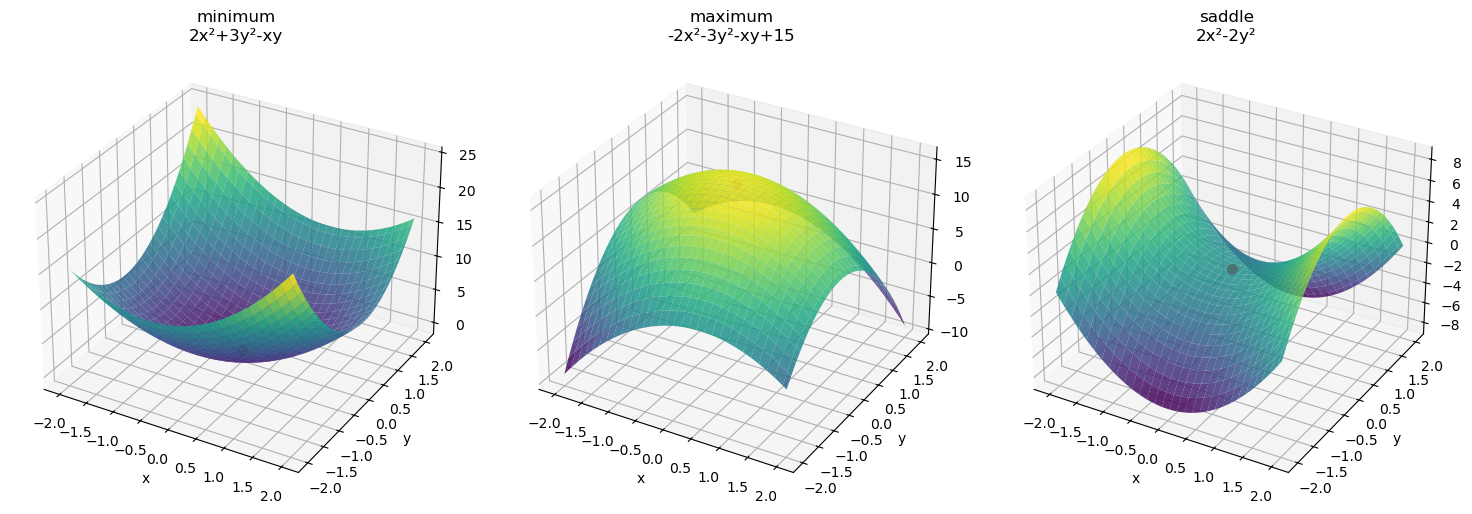

In [4]:
gx = np.linspace(-2, 2, 60); gy = np.linspace(-2, 2, 60)
X, Y = np.meshgrid(gx, gy)
surfaces = [("minimum\n2x²+3y²-xy", 2*X**2+3*Y**2-X*Y),
            ("maximum\n-2x²-3y²-xy+15", -2*X**2-3*Y**2-X*Y+15),
            ("saddle\n2x²-2y²", 2*X**2-2*Y**2)]

fig = plt.figure(figsize=(15, 5))
for i, (title, Z) in enumerate(surfaces, 1):
    ax = fig.add_subplot(1, 3, i, projection="3d")
    ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.85)
    ax.scatter([0], [0], [Z[30, 30]], color="red", s=50)
    ax.set_title(title)
    ax.set_xlabel("x"); ax.set_ylabel("y")
plt.tight_layout()
plt.show()

## 6. The summary table

| nature of critical point | one variable | two variables | $n$ variables |
|---|---|---|---|
| local **minimum** | $f''(x) > 0$ | both eigenvalues $> 0$ | all $n$ eigenvalues $> 0$ |
| local **maximum** | $f''(x) < 0$ | both eigenvalues $< 0$ | all $n$ eigenvalues $< 0$ |
| **otherwise** | $f''(x) = 0$ (inconclusive) | one $>0$, one $<0$ (saddle) | mixed / any zero (inconclusive) |

In all cases the point must first satisfy $\nabla f = 0$ (a critical point).

In [5]:
def classify(expr, x0=0, y0=0):
    H = np.array(sp.hessian(expr, (x, y)).subs({x: x0, y: y0})).astype(float)
    eig = np.linalg.eigvalsh(H)
    if np.all(eig > 0):   kind = "local MINIMUM (positive definite)"
    elif np.all(eig < 0): kind = "local MAXIMUM (negative definite)"
    elif np.any(np.isclose(eig, 0)): kind = "INCONCLUSIVE (a zero eigenvalue)"
    else: kind = "SADDLE point (indefinite)"
    return eig, kind

for expr in (f1, f2, f3):
    eig, kind = classify(expr)
    print(f"{str(expr):24s}  eigs={np.round(eig,3)}  -> {kind}")

2*x**2 - x*y + 3*y**2     eigs=[3.586 6.414]  -> local MINIMUM (positive definite)
-2*x**2 - x*y - 3*y**2 + 15  eigs=[-6.414 -3.586]  -> local MAXIMUM (negative definite)
2*x**2 - 2*y**2           eigs=[-4.  4.]  -> SADDLE point (indefinite)


## 7. Exercises

### Basic
1. What do you examine to classify a critical point in two variables?
2. What does it mean for the Hessian to be positive definite?

### Intermediate
3. Classify the critical point of $f(x,y) = x^2 + 4y^2$ at the origin.
4. Classify the critical point of $f(x,y) = -x^2 - y^2$ at the origin.

### Advanced
5. Classify the origin for $f(x,y) = x^2 - 3y^2$ and explain the shape.
6. For $f(x,y) = x^2 + y^3$, compute the Hessian at $(0,0)$ and explain why the test is
   inconclusive there.

## 8. Solutions / Checks

In [6]:
for expr in (x**2 + 4*y**2, -x**2 - y**2, x**2 - 3*y**2, x**2 + y**3):
    eig, kind = classify(expr)
    print(f"{str(expr):14s}  eigs={np.round(eig,3)}  -> {kind}")

print("\n1. The eigenvalues of the Hessian (after checking ∇f = 0).")
print("2. All its eigenvalues are positive -> the surface curves up in every direction.")
print("6. f''=diag(2,0) at origin: a zero eigenvalue makes the test inconclusive "
      "(the y³ term needs higher-order analysis).")

x**2 + 4*y**2   eigs=[2. 8.]  -> local MINIMUM (positive definite)
-x**2 - y**2    eigs=[-2. -2.]  -> local MAXIMUM (negative definite)
x**2 - 3*y**2   eigs=[-6.  2.]  -> SADDLE point (indefinite)
x**2 + y**3     eigs=[0. 2.]  -> INCONCLUSIVE (a zero eigenvalue)

1. The eigenvalues of the Hessian (after checking ∇f = 0).
2. All its eigenvalues are positive -> the surface curves up in every direction.
6. f''=diag(2,0) at origin: a zero eigenvalue makes the test inconclusive (the y³ term needs higher-order analysis).


## 9. Conclusion

- The Hessian generalizes the second-derivative test to many variables via its
  **eigenvalues**.
- **All positive** → positive definite → **minimum**; **all negative** → negative definite
  → **maximum**; **mixed signs** → **saddle**; **any zero** → inconclusive.
- The three model surfaces — bowl, dome, saddle — show each case visually.
- Combined with $\nabla f = 0$, this fully classifies critical points, and it's the
  curvature information **Newton's method in two variables** uses — the next topic.

## Appendix — Source transcript

Transcribed with OpenAI Whisper (`small.en`) from a locally downloaded video
(`~/Downloads/index (2).mp4`), the Coursera *Calculus for Machine Learning and Data
Science* (Week 3) lecture on **Hessians and concavity**. Key spoken points, lightly cleaned:

> In one variable, $f'' > 0$ means concave up (a local minimum), $f'' < 0$ concave down (a
> local maximum), and $f'' = 0$ is inconclusive. The same holds for many variables, but now
> the second derivative is the Hessian matrix — and to check whether a matrix is "positive"
> or "negative" you look at its eigenvalues. For $2x^2 + 3y^2 - xy$ the Hessian eigenvalues
> are about $6.41$ and $3.59$, both positive → positive definite → concave up → the origin
> is a minimum. For $-2x^2 - 3y^2 - xy + 15$ the eigenvalues are about $-3.59$ and $-6.41$,
> both negative → negative definite → maximum. For $2x^2 - 2y^2$ the Hessian is
> $\begin{bmatrix} 4 & 0 \\ 0 & -4 \end{bmatrix}$ with eigenvalues $4$ and $-4$ — mixed
> signs, so neither definite: a saddle point. Summary: all eigenvalues positive → minimum,
> all negative → maximum, anything else (mixed signs or a zero) → inconclusive by this test.